In [ ]:
import pandas as pd
import numpy as np
from textblob import TextBlob

# 1. Load your downloaded Kaggle dataset (adjust file name/path as needed)
df = pd.read_csv("data/Bitext_Banking_Intent.csv")

# 2. Run NLP Sentiment Analysis on the 'instruction' column
print("Calculating customer sentiment trends...")
df['Sentiment_Score'] = df['instruction'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# 3. Create a Customer Satisfaction (CSAT) score based on sentiment
# Maps sentiment (-1 to 1) to a standard 1-5 bank rating scale
df['CSAT_Rating'] = np.interp(df['Sentiment_Score'], [-1, 1], [1, 5]).round(0).astype(int)

# 4. Synthesize Operational Engine Logs (To showcase system performance)
# Generate realistic response times in milliseconds (e.g., between 150ms and 1200ms)
np.random.seed(42)
df['Response_Time_ms'] = np.random.randint(150, 1200, size=len(df))

# Generate randomized channel origins to simulate an omnichannel infrastructure
channels = ['Telegram Bot', 'WhatsApp Banking', 'Mobile App', 'Web Chat']
df['Channel'] = np.random.choice(channels, size=len(df), p=[0.40, 0.35, 0.15, 0.10])

# Generate random status logs (Success vs System Timeout Error)
df['Status'] = np.random.choice(['Success', 'System Error', 'Timeout'], size=len(df), p=[0.92, 0.05, 0.03])

# 5. Generate random dates over a 30-day period to allow for DAX Time Intelligence
start_date = pd.to_datetime('2026-05-01')
df['Timestamp'] = start_date + pd.to_timedelta(np.random.randint(0, 30*24*60, size=len(df)), unit='m')

# 6. Separate into Fact and Dimension Tables for a clean Star Schema
# Fact Table (Logs & Metrics)
fact_bot_logs = df[['Timestamp', 'Channel', 'category', 'intent', 'Response_Time_ms', 'Status', 'CSAT_Rating', 'Sentiment_Score']]
fact_bot_logs.to_csv("Fact_Bot_Logs.csv", index=False)

# Dimension Table (Unique Text Mappings)
dim_intents = df[['category', 'intent', 'instruction', 'response']].drop_duplicates(subset=['intent']).reset_index(drop=True)
dim_intents.to_csv("Dim_Intents.csv", index=False)

print("Data engineered successfully! Your files 'Fact_Bot_Logs.csv' and 'Dim_Intents.csv' are ready for Power BI.")

FileNotFoundError: [Errno 2] No such file or directory: 'data//Bitext_Banking_Intent.csv'

Number of rows
Number of columns
Missing values
Data types

In [3]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(11162, 17)
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


Data Cleaning:
 Handle Missing Values

In [5]:
df.isnull().sum()
#if there are missing values, you can handle them using various strategies such as filling with mean/median/mode, forward fill, backward fill, or dropping the rows/columns with missing values.
df.fillna(0, inplace=True)#Filling missing values with 0, you can choose other strategies based on the context of your data.

Remove Duplicates

In [7]:
# After handling missing values, we can check for duplicates.
df.duplicated().sum()
# If there are duplicates, you can drop them using the following code:
df.drop_duplicates(inplace=True)

Customer Analysis

In [10]:
df["age"].describe()

count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

Create chart
To answer questions like:
Average age?
Young vs old customers?
Largest age group?

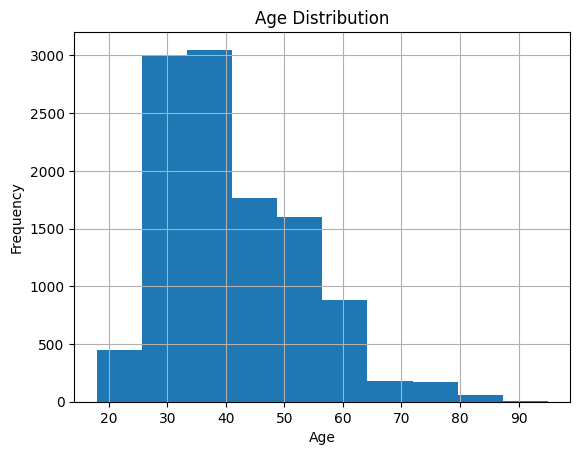

<Figure size 1000x600 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt

df["age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.figure(figsize=(10, 6))
plt.show()

Branch Analysis

In [18]:
df.groupby("branch")["balance"].sum()

KeyError: 'branch'